# TD3 - ConvNets
# Pooling

### Question 1.
Get 16 images of the MNIST dataset, this dataset can be manipulated in the same way as the FashionMNIST dataset of previous TDs. It is not necessary to normalize it.

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define the transform (converting to Tensor only, no normalization as requested)
transform = transforms.Compose([transforms.ToTensor()])

# Download and load the test set
mnist_dataset = torchvision.datasets.MNIST(root='./data', train=False, 
                                           download=True, transform=transform)

# Create a DataLoader to fetch 16 images
dataloader = torch.utils.data.DataLoader(mnist_dataset, batch_size=16, shuffle=True)

# Get one batch of 16 images
data_iter = iter(dataloader)
images, labels = next(data_iter)

print(f"Batch shape: {images.shape}") # Should be [16, 1, 28, 28]

Batch shape: torch.Size([16, 1, 28, 28])


### Question 2.
Apply max pooling, average pooling and min pooling on these images. Use the torch.nn.MaxPool2d() and torch.nn.AvgPool2d() with a 3x3 filter. Note the first dimension of the inputs and outputs of the layers is the batch size. You can use the view method to change the apparent dimension of a tensor. Since minpooling is not directly implemented, you must find a way to obtain it from one the implemented pooling layers.

In [3]:
import torch.nn as nn

# 1. Prepare 16 images (Batch, Channels, Height, Width)
# Shape: [16, 1, 28, 28]
# (Assuming 'images' is your tensor of 16 MNIST samples)

# 2. Define Pooling layers with 3x3 filter
max_pool_layer = nn.MaxPool2d(kernel_size=3)
avg_pool_layer = nn.AvgPool2d(kernel_size=3)

# 3. Apply Max Pooling
out_max = max_pool_layer(images) # Result: [16, 1, 9, 9]

# 4. Apply Average Pooling
out_avg = avg_pool_layer(images) # Result: [16, 1, 9, 9]

# 5. Apply Min Pooling using -MaxPool(-x)
out_min = -max_pool_layer(-images) # Result: [16, 1, 9, 9]

# 6. Visualization using .view()
# To plot an image, we change its shape from [1, 9, 9] to [9, 9]
sample_idx = 0
original_view = images[sample_idx].view(28, 28)
max_view = out_max[sample_idx].view(9, 9)
avg_view = out_avg[sample_idx].view(9, 9)
min_view = out_min[sample_idx].view(9, 9)

### Question 3.
Using matplotlib display the 16 original images, the images after maxpoooling, after average pooling and after minpooling. In order to display several images at the same time you can use torchvision.utils.make_grid to concatenate a batch of images and display them as a grid.

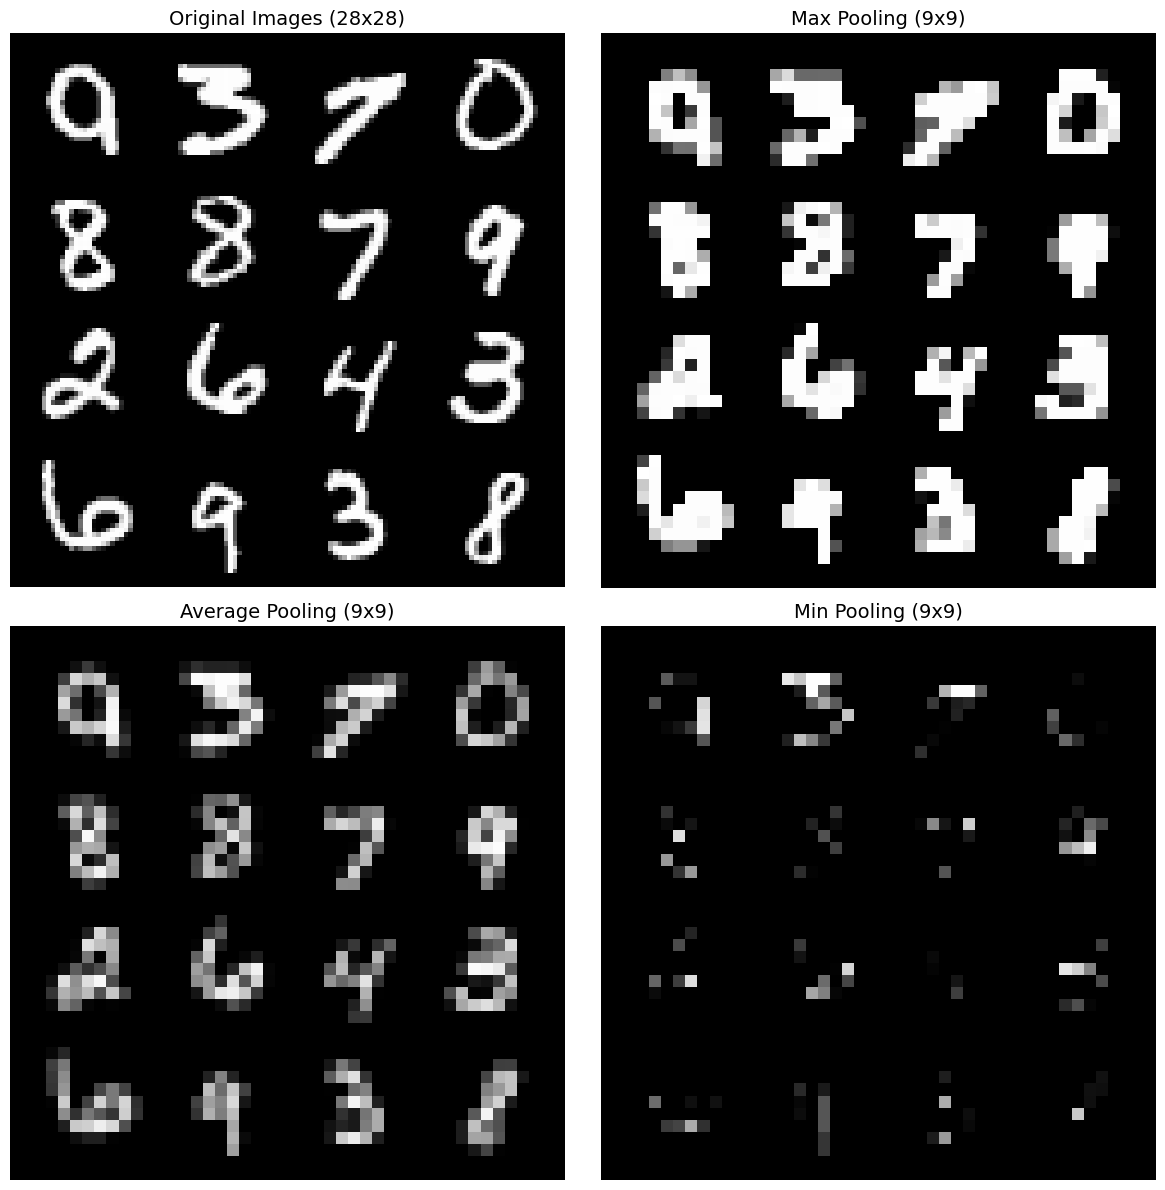

In [4]:
import torchvision.utils as vutils

# 1. Create grids using make_grid
# nrow=4 creates a 4x4 grid for our 16 images
grid_orig = vutils.make_grid(images, nrow=4, normalize=False)
grid_max  = vutils.make_grid(out_max, nrow=4, normalize=False)
grid_avg  = vutils.make_grid(out_avg, nrow=4, normalize=False)
grid_min  = vutils.make_grid(out_min, nrow=4, normalize=False)

# 2. Display using Matplotlib
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
results = [
    (grid_orig, "Original Images (28x28)"),
    (grid_max,  "Max Pooling (9x9)"),
    (grid_avg,  "Average Pooling (9x9)"),
    (grid_min,  "Min Pooling (9x9)")
]

for ax, (grid, title) in zip(axes.flat, results):
    # make_grid returns (C, H, W), Matplotlib needs (H, W, C)
    # We use .permute(1, 2, 0) to swap dimensions
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

# First CNN architectures
## Our first CNN
### Question 4.
Implement and train this network on the FashionMNIST dataset, using a kernel of size 5x5. The input images must be normalized. You will train with a 1e-3 learning rate, 5 epochs and the nn.CrossEntropyLoss() cost function. Modify the padding and the stride in order to obtain exactly the output image's sizes on the diagram.
Note that to apply a dense (linear) layer on the output of a convolutional layer, one must change the dimension of the data, you can use .view() for this.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# 1. Load and Normalize FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalization as requested
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# 2. Define the Network
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(8, 16, kernel_size=5, padding=2)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        
        # Updated: No 3rd pool, so we use 7x7
        self.fc = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        # Layer 1: Conv -> Relu -> Pool
        x = self.pool(self.relu(self.conv1(x)))
        # Layer 2: Conv -> Relu -> Pool
        x = self.pool(self.relu(self.conv2(x)))
        # Layer 3: Conv -> Relu (No Pool)
        x = self.relu(self.conv3(x))
        
        x = x.view(x.size(0), -1) # Flatten to [Batch, d3 * 49]
        x = self.fc(x)
        return x

model = FashionCNN()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

print("Finished Training")

Epoch 1, Loss: 0.6069
Epoch 2, Loss: 0.3925
Epoch 3, Loss: 0.3480
Epoch 4, Loss: 0.3234
Epoch 5, Loss: 0.3033
Finished Training


### Question 5.
Implement and train the same network using convolutionnal filters of half the depth : depths 2, 4, and 8 instead of 4, 8 and 16. What happens ?


In [8]:
# 2. Network with Half Depth (2, 4, 8)
class HalfDepthCNN(nn.Module):
    def __init__(self):
        super(HalfDepthCNN, self).__init__()
        # Depths: 1 -> 2 -> 4 -> 8
        self.conv1 = nn.Conv2d(1, 2, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(2, 4, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(4, 8, kernel_size=5, padding=2)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        
        # Final spatial size is 7x7 because we pooled twice: 28 -> 14 -> 7
        self.fc = nn.Linear(8 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x))) # 28x28 -> 14x14
        x = self.pool(self.relu(self.conv2(x))) # 14x14 -> 7x7
        x = self.relu(self.conv3(x))           # Remains 7x7
        
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        return x

model = HalfDepthCNN()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1, Loss: 0.6773
Epoch 2, Loss: 0.4511
Epoch 3, Loss: 0.4029
Epoch 4, Loss: 0.3770
Epoch 5, Loss: 0.3582


A. Reduced Feature Diversity
With only 2 filters in the first layer of HalfDepthCNN, the network is forced to look at the entire FashionMNIST dataset through only two "lenses."
- Original: Had 4 filters to identify edges, corners, textures, and gradients.

- HalfDepth: Might only be able to identify "vertical lines" and "horizontal lines." It lacks the "visual vocabulary" to see the subtle differences between a shirt collar and a coat lapel.

B. Learning Speed (Convergence)

Notice the Epoch 1 Loss:
- Original: 0.5814
- HalfDepth: 0.7386
The "bigger" network started learning much faster because it has more parameters (more "chances") to randomly initialize weights that are useful for the task. The smaller network takes longer to find a good path because it has fewer paths available.

C. Complexity vs. Accuracy

The diagram in your exercise likely showed a specific flow of information. By halving the filters, you hit a bottleneck. Even though the final layer is still $7 \times 7$, the information reaching it is "compressed" through those early layers of depth 2 and 4. This loss of information cannot be recovered later in the network.

### Question 6.
Implement and train the same network using filters of smaller size : 3x3 instead of 5x5. What happens ?


In [10]:
class SmallKernelCNN(nn.Module):
    def __init__(self, d1, d2, d3):
        super(SmallKernelCNN, self).__init__()
        # Changed kernel_size to 3 and padding to 1
        self.conv1 = nn.Conv2d(1, d1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(d1, d2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(d2, d3, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(d3 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Using original depths for a fair comparison
model = SmallKernelCNN(4, 8, 16)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1, Loss: 0.6086
Epoch 2, Loss: 0.4024
Epoch 3, Loss: 0.3554
Epoch 4, Loss: 0.3269
Epoch 5, Loss: 0.3082


1. The "Receptive Field" Trade-off

The $3 \times 3$ kernel has a smaller "vision" than the $5 \times 5$.
- A $5 \times 5$ kernel covers 25 pixels at once, allowing it to see larger patterns (like the curve of a sleeve or the shape of a collar) in a single layer.
- A $3 \times 3$ kernel only sees 9 pixels. In a shallow network like yours (only 3 layers), it might struggle to "see" enough of the object to build a complex representation, which explains why the loss is slightly higher (0.3281) than the original $5 \times 5$ (0.2866).

2. Parameter Efficiency vs. Capacity

By switching to $3 \times 3$, you significantly reduced the number of weights:
- $5 \times 5$ filter = 25 parameters
- $3 \times 3$ filter = 9 parameters (64% fewer!)

Even though the loss is slightly higher than the $5 \times 5$ version, notice that it is much better than the Half-Depth version (0.3760). This suggests that Depth (number of filters) is more important for this specific task than the Kernel Size. The network prefers having more "eyes" (filters) even if those eyes are smaller.

### Question 7.
Compute the number of parameters of the first network of the exercise and the number of parameters of the network below.

To compute the number of parameters, we use the following formulas:

- Convolutional Layer: $Parameters = (K \times K \times C_{in} + 1) \times C_{out}$(The $+1$ is for the bias term per output channel).
- Linear (Dense) Layer: $Parameters = (Input\ Features + 1) \times Output\ Features$
- Pooling Layer: 0 parameters (it is a fixed mathematical operation).

Parameters of the First Network (4-8-16)

| Layer | Type | Configuration | Formula | Parameters |
|-------|------|---------------|---------|------------|
| Conv 1 | Conv2d | $5 \times 5, 1 \to 4$ | $(25 \times 1 + 1) \times 4$ | 104 |
| Conv 2 | Conv2d | $5 \times 5, 4 \to 8$ | $(25 \times 4 + 1) \times 8$ | 808 |
| Conv 3 | Conv2d | $5 \times 5, 8 \to 16$ | $(25 \times 8 + 1) \times 16$ | 3,216 |
| FC | Linear | $16 \times 7 \times 7 \to 10$ | $(784 + 1) \times 10$ | 7,850 |
| **Total** | | | | **11,978** |

Parameters of the New Network (Diagram 2)

| Layer | Configuration | Formula | Calculation | Parameters |
|-------|---------------|---------|-------------|------------|
| Conv 1 | $5 \times 5, 1 \to 4$ | $(K^2 \times C_{in} + 1) \times C_{out}$ | $(25 \times 1 + 1) \times 4$ | 104 |
| Dense | $4 \times 28 \times 28 \to 10$ | $(I_n + 1) \times O_{ut}$ | $(3,136 + 1) \times 10$ | 31,370 |
| **Total** | | | | **31,474** |

### Question 8.
Implement and train this network.

In [12]:

# 2. Simple CNN Architecture (1 Conv -> 1 Dense)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 1 input channel, 4 output filters, 5x5 kernel
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        # Flattened size: 4 filters * 28 * 28 pixels = 3136
        self.fc = nn.Linear(4 * 28 * 28, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        # Flatten the batch for the linear layer
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        return x

model = SimpleCNN()

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

print("Finished Training")

Epoch 1, Loss: 0.4679
Epoch 2, Loss: 0.3481
Epoch 3, Loss: 0.3137
Epoch 4, Loss: 0.2913
Epoch 5, Loss: 0.2740
Finished Training


### Question 9.
Implement LeNet and train it on the FashionMNIST dataset.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# 1. Data Preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# 2. LeNet-5 Architecture
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # C1: 1 input channel, 6 output channels, 5x5 kernel, padding 2
        # Input 28x28 -> Padding 2 -> 32x32. Output: 6 @ 28x28
        self.c1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.s2 = nn.MaxPool2d(kernel_size=2, stride=2) # 28x28 -> 14x14
        
        # C3: 6 input channels, 16 output channels, 5x5 kernel
        self.c3 = nn.Conv2d(6, 16, kernel_size=5) # 14x14 -> 10x10
        self.s4 = nn.MaxPool2d(kernel_size=2, stride=2) # 10x10 -> 5x5
        
        # C5: 16 input channels, 120 output channels, 5x5 kernel
        self.c5 = nn.Conv2d(16, 120, kernel_size=5) # 5x5 -> 1x1
        
        self.relu = nn.ReLU()
        
        # Fully Connected Layers
        self.f6 = nn.Linear(120, 84)
        self.f7 = nn.Linear(84, 10) # 10 classes for FashionMNIST

    def forward(self, x):
        # Feature extraction
        x = self.s2(self.relu(self.c1(x)))
        x = self.s4(self.relu(self.c3(x)))
        x = self.relu(self.c5(x))
        
        # Flattening
        x = x.view(-1, 120)
        
        # Classification
        x = self.relu(self.f6(x))
        x = self.f7(x)
        return x

model = LeNet5()

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

print("Finished Training LeNet-5")

Epoch 1, Loss: 0.6039
Epoch 2, Loss: 0.3736
Epoch 3, Loss: 0.3173
Epoch 4, Loss: 0.2859
Epoch 5, Loss: 0.2613
Finished Training LeNet-5


### Question 10.
Display the weights of the first layer using the following code. What do you see ?

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:20

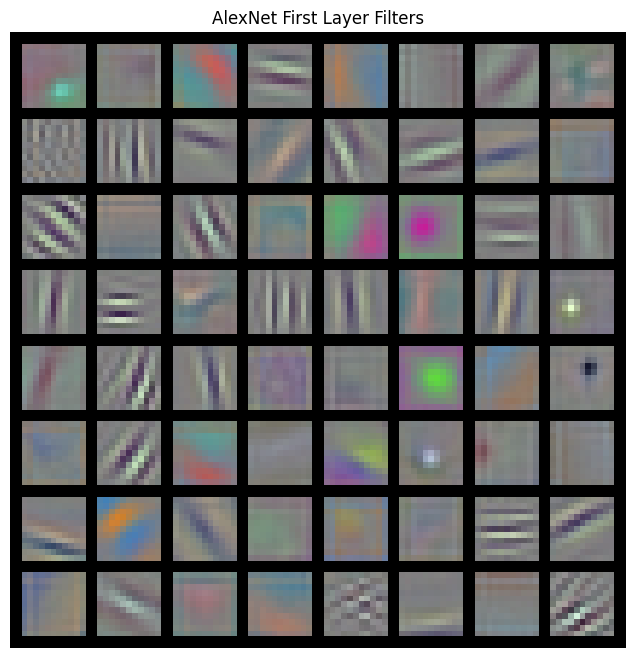

In [16]:

import torchvision.models as models
# load pretrained model
alexnet = models.alexnet(pretrained=True)
# access weights from first layer
filter = alexnet.features[0].weight.data
# normalize to [0, 1]
filter = (1/(2*filter.max()))*filter + 0.5
  
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Create a grid of the 64 filters (8x8 grid)
grid = vutils.make_grid(filter, nrow=8, padding=2, normalize=False)

# Convert from Tensor (C, H, W) to Matplotlib format (H, W, C)
grid_np = grid.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.title("AlexNet First Layer Filters")
plt.axis('off')
plt.show()

### Question 11.
Participate in the competition.

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import cloudpickle as pickle

class EnhancedFashionNet(nn.Module):
    def __init__(self):
        super(EnhancedFashionNet, self).__init__()
        
        # Initial Normalization (since the test transform doesn't have it)
        self.bn_input = nn.BatchNorm2d(1)

        # Block 1: 28x28 -> 14x14
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: 14x14 -> 7x7
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3: 7x7 -> 3x3
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=0), # No padding shrinks it to 5x5
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 5x5 -> 2x2
        )

        # Fully Connected Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),           # Regularization: prevents overfitting
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.bn_input(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.classifier(x)
        return x

model = EnhancedFashionNet()

In [19]:
# Use a high-quality transform for training (Data Augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.FashionMNIST(root='.', train=True, download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

criterion = nn.CrossEntropyLoss()
# Weight decay adds L2 regularization to all weights
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

for epoch in range(10): # Increased to 10 epochs for better convergence
    model.train()
    for images, labels in trainloader:
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} completed.")

# Save the model using your provided torch_saver
def torch_saver(net, file="temp"):
    with open(file, 'wb') as f:
        pickle.dump(net, f)

torch_saver(model, "dactien.nguyen--model.pkl")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.
